In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  


In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from region import Region
from functions import Functions
fns = Functions()

In [4]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pickle
from cartopy.feature import LAND

In [ ]:
# load raw data
sla_ = SLA(deg=0.25).da
elevation_ = GEBCO(coarsen_factor=4).ds.elevation
winds_ = xr.open_dataset('../data/ef25db236e60a21a34ee2e0b4631d366.nc').sortby('latitude').rename({'valid_time':'time'})
sam = Index(type='SAM').da.sel(time=slice(sla_.time[0],sla_.time[-1]))
dotds = DOT().ds.rename({'ug':'u10','vg':'v10'})
sice_ = xr.open_dataset('../data/NSIDC/sice_processed.nc').__xarray_dataarray_variable__
gyre_index = xr.open_dataarray('gyre_index.nc')

# lwe_ds = GRACE().ds
# sha_ds_sla = StericHeight(ssh_ref='DOT',
#                       ssh=sla_,#SLA(deg=1).da,
#                       msl=None,
#                       lwe=lwe_ds.lwe_thickness
#                       ).get_sha()



In [ ]:
# define areas of interest and crop elevation for plotting speed
extent_ac = [138,152,-68,-63]
extent_ea = [60,160,-70,-60]

elevation_ea = elevation_.sel(latitude = slice(extent_ea[2], extent_ea[3]), longitude = slice(extent_ea[0],extent_ea[1]))
elevation_ac = elevation_.sel(latitude = slice(extent_ac[2], extent_ac[3]), longitude = slice(extent_ac[0],extent_ac[1]))

In [12]:
# crop data to required areas
region_ac = Region('AC',extent_ac,elevation=elevation_ac)
region_ac_shelf = Region('ACS',extent_ac,elevation=elevation_ac,min_elevation=-1000)
region_ea = Region('EA',extent_ea)

extent_gyre = [145,149,-66.5,-65.5]
region_gyre = Region('Gyre',extent=extent_gyre)

winds_ea = region_ea.crop_da(winds_)

sla = region_ac.crop_da(sla_)
sla_shelf = region_ac_shelf.crop_da(sla_)
sla_gyre = region_gyre.crop_da(sla_)
winds = region_ac.crop_da(winds_)
# dot =region_ac.crop_da(dotds)
sice = region_ac.crop_da(sice_)
sic_shelf = region_ac_shelf.crop_da(sice_)
# lwe_shelf = region_ac_shelf.crop_da(lwe_ds)
# sha_shelf = region_ac_shelf.crop_da(sha_ds_sla)

# filter dodgy sla signal
lonboo = sla.longitude < 147
latboo = sla.latitude > -66.6
sla = sla.where(lonboo | latboo,drop=True)

In [ ]:
# compute geostrophc currents and detrend

u,v = fns.get_geostrophic_currents(sla)
geos = xr.Dataset({'u10':u,'v10':v})

dtu = utls.detrend_dim(u,dim='time')
dtv = utls.detrend_dim(v,dim='time')
dt_geos = xr.Dataset({'u10':dtu,'v10':dtv})

# also detrend the wind, SIC nd SLA
dt_winds = xr.Dataset({
    'u10': utls.detrend_dim(winds.u10,'time'),
    'v10': utls.detrend_dim(winds.v10,'time')
})

dt_sic = utls.detrend_dim(sice.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])),'time')
dt_sla = utls.detrend_dim(sla.interpolate_na(dim='time'),'time')


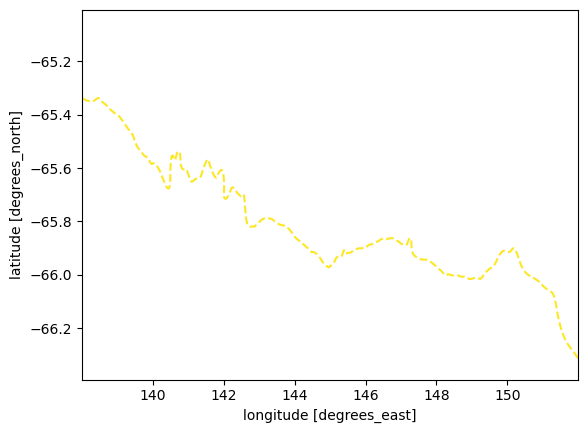

In [13]:
# USE contur plot to isolate coords of -1000 isobath
cc=elevation_ac.sel(latitude=slice(-66.4,-65)).plot.contour(levels=[-1000])

In [ ]:
# get coords from contour
lats = xr.DataArray(cc.allsegs[0][0].T[1],coords={'longitude':cc.allsegs[0][0].T[0]})
asclats = lats.sortby('longitude').interp(longitude=geos.longitude,kwargs={'fill_value':'extrapolate'})

# get geostrophic currents along the slope
geos['asc_latitude'] = xr.DataArray(asclats,coords={'longitude':geos.longitude})
geos['asc'] = geos.u10.sel(latitude=geos.asc_latitude,method='nearest')

# turn into radians for vector mathematics
R = 6371000
lat_radians = np.deg2rad(geos.asc_latitude)

# find x and y distnace between each point onthe contour
dx = R * np.cos(lat_radians[:-1]) * np.deg2rad(np.diff(geos.longitude))
dy = R * np.deg2rad(np.diff(geos.asc_latitude))

# FIND linear distance between each point on the contour
delta = np.stack([dx,dy],axis=1)
t_hat = delta / np.linalg.norm(delta, axis=1)[:, None]

# Interpolate u and v onto path points for all times
u_path = geos.u10.interp(latitude=geos.asc_latitude, longitude=geos.longitude)
v_path = geos.v10.interp(latitude=geos.asc_latitude, longitude=geos.longitude)

# We project using the unit vector of each segment; use the starting point of each segment
u_seg = u_path[:, :-1]  # drop last point (segments)
v_seg = v_path[:-1, :]

In [16]:
dathatx = xr.DataArray(t_hat[:,0],coords={'longitude':u_seg.longitude})
dathaty = xr.DataArray(t_hat[:,1],coords={'longitude':u_seg.longitude})
v_along = u_seg * dathatx + v_seg * dathaty # shape: (time, segments)

In [17]:
# strength of easterlies and westerlies
eastl = -winds.u10.sel(latitude=slice(-68,-65)).mean(['latitude','longitude'])
westl = winds.u10.sel(latitude=slice(-64,-55)).mean(['latitude','longitude'])
# strength of ASC/ACC
#asc = geos.u10.sel(latitude=slice(-66.25,-65.5)).mean(['latitude','longitude'])
acc = geos.u10.sel(latitude=slice(-65,-63)).mean(['latitude','longitude'])
# coastal ssh
cssh = sla_shelf.mean(['latitude','longitude'])
csic = sic_shelf.mean(['latitude','longitude'])
gssh = sla_gyre.mean(['latitude','longitude'])
# sha & grace
csha = sha_shelf.sha.mean(['latitude','longitude'])
clwe = lwe_shelf.lwe_thickness.mean(['latitude','longitude'])

In [18]:
# new asc
asc = -v_along.mean('longitude')

In [19]:
dt_eastl = utls.detrend_dim(eastl,'time')
dt_westl = utls.detrend_dim(westl,'time')
dt_acc = utls.detrend_dim(acc,'time')
dt_asc = utls.detrend_dim(asc,'time')
dt_cssh = utls.detrend_dim(cssh,'time')
dt_csic = utls.detrend_dim(csic,'time')
dt_eastl = utls.detrend_dim(eastl,'time')
dt_sam = utls.detrend_dim(sam,'time')


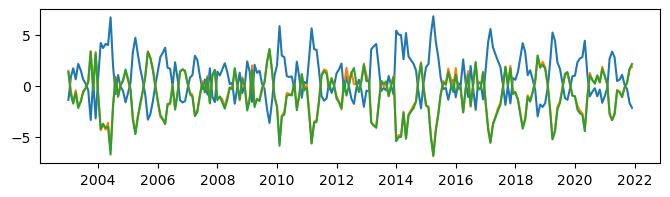

In [20]:
fig,ax = plt.subplots(figsize=(8,2))
ax.plot(geos.time,asc)
ax.plot(geos.time,geos.asc.mean('longitude'))
ax.plot(geos.time,v_along.mean('longitude'))

In [21]:
#repeat with extra plots
sose145 = xr.open_dataset('sose_shelf_145.nc')
glorys = xr.open_dataset('glorys_shelf_145.nc')

In [22]:
sigdiff = xr.open_dataarray('sigdiff.nc')

In [23]:
# make glorys look like sose
mglorys = glorys.sel(longitude = 145,method='nearest').sel(latitude=slice(sose145.YC.min(),sose145.YC.max())).mean('latitude')

In [66]:
dt_glorys_theta = utls.detrend_dim(mglorys.thetao,'time')
dt_glorys_psal = utls.detrend_dim(mglorys.so,'time')

In [78]:
ssal = sose145.SALT.sel(Z=slice(0,-500)).mean(['Z','YC'])
sthe = sose145.THETA.sel(Z=slice(0,-500)).mean(['Z','YC'])

s_top100t = -sose145.THETA.sel(Z=slice(0,-100)).integrate('Z').mean('YC')
s_top100s = -sose145.SALT.sel(Z=slice(0,-100)).integrate('Z').mean('YC')

s_breakt = -sose145.THETA.sel(Z=slice(200,400)).integrate('Z').sel(YC = slice(-66.5,-66)).mean('YC')
s_breaks = -sose145.SALT.sel(Z=slice(200,400)).integrate('Z').sel(YC = slice(-66.5,-66)).mean('YC')


dt_ssal = utls.detrend_dim(ssal,'time')
dt_sthe = utls.detrend_dim(sthe,'time')

dt_ssal100 = utls.detrend_dim(s_top100s,'time')
dt_sthe100 = utls.detrend_dim(s_top100t,'time')

dt_sbreaks = utls.detrend_dim(s_breaks,'time')
dt_sbreakt = utls.detrend_dim(s_breakt,'time')


dt_gi = utls.detrend_dim(gyre_index,'time')

Rendering..


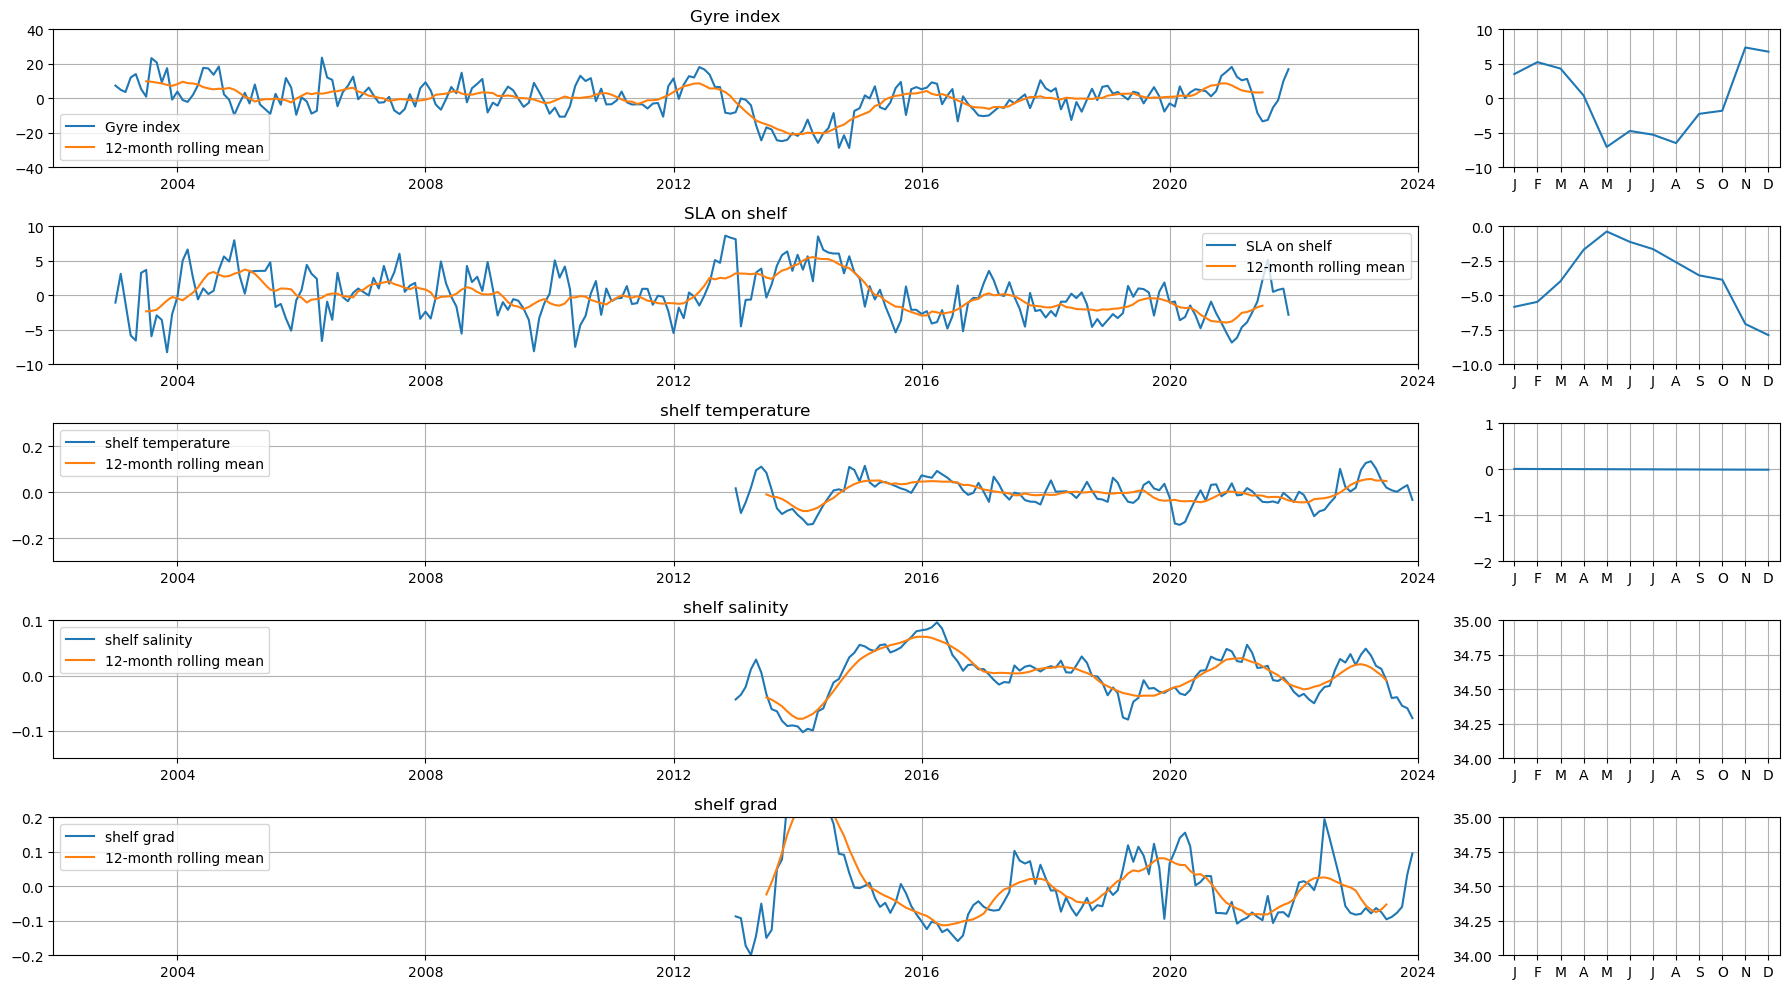

In [70]:
fig = plt.figure(figsize=(18,10))
axs=[]

gs = fig.add_gridspec(5,5)

def add_row(n,var,varname,ylim=[-16,16],ylim_cmt=[-7,7],anom=False):

    axs.append(fig.add_subplot(gs[n,0:4]))
    axs.append(fig.add_subplot(gs[n,4:6]))

    if 'latitude' in var.dims:
        da = var.mean(['latitude','longitude'])
    else:
        da = var
        
    cmt = da.groupby('time.month').mean()

    ax = axs[(n*2)]

    if anom:
        da = da.groupby('time.month') - cmt
        #varname = varname + ' (seasonal anomaly)'

    ax.plot(da.time,da,label=varname)
    ax.plot(da.time,da.rolling(time=12,center=True).mean(),label='12-month rolling mean')

    ax.set_title(varname)
    ax.legend(loc='best')
    ax.set_ylim(ylim)
    ax.set_xlim([pd.Timestamp(2002,1,1),pd.Timestamp(2024,1,1)])
    ax.grid()

    ax = axs[(n*2)+1]

    ax.plot(cmt.month,cmt)
    ax.set_ylim(ylim_cmt)
    ax.grid()
    ax.set_xticks(cmt.month,labels=['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_xlim([0.5,12.5])


sd2 = xr.open_dataarray('sigdiff2.nc')

add_row(0,gyre_index,'Gyre index',anom=True,ylim=[-40,40],ylim_cmt=[-10,10])
add_row(1,cssh,'SLA on shelf',anom=True,ylim=[-10,10],ylim_cmt=[-10,0])
add_row(2,dt_sthe,'shelf temperature',anom=True,ylim=[-0.3,0.3],ylim_cmt=[-2,1])
add_row(3,dt_ssal,'shelf salinity',anom=True,ylim=[-0.15,0.1],ylim_cmt=[34,35])
add_row(4,sd2,'shelf grad',anom=True,ylim=[-0.2,0.2],ylim_cmt=[34,35])





plt.tight_layout()
print('Rendering..')


In [71]:

var1 = fns.seasonal_anomaly(dt_ssal)# sose145.SALT.integrate('Z').mean(['YC']
vars = [fns.seasonal_anomaly(var) for var in [dt_cssh,dt_westl,dt_eastl,dt_asc,dt_sam,dt_acc,dt_csic]]


lags = np.arange(-12,13,1)
cmat = np.empty((len(vars),len(lags)))
pmat = np.empty((len(vars),len(lags)))


ts = cssh.time[0]

for i,v in enumerate(vars):
    for j,w in enumerate(lags):
        var1_shifted = var1.assign_coords(
            time=pd.to_datetime(var1.time.values) + pd.DateOffset(months=w)
        )
        vw, wv = xr.align(v,var1_shifted)#.shift({'time':w}))
        cmat[i][j] = xr.corr(vw,wv).item()
        pmat[i][j] = pearsonr(vw, wv)[1]

In [72]:
matt = pd.DataFrame(cmat.T,columns=['SLA','W-LIES','E-LIES','ASC','SAM','ACC','SIC'],index=[str(n) for n in lags])

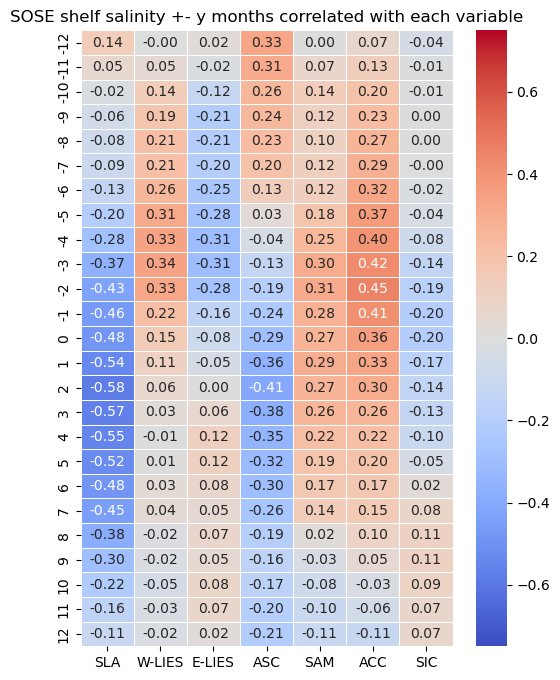

In [73]:
plt.figure(figsize=(6,8))
sns.heatmap(matt, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-0.75,vmax=0.75)
plt.title("SOSE shelf salinity +- y months correlated with each variable")
plt.show()

In [74]:
def mshift(da,m):
    return da.assign_coords(
            time=pd.to_datetime(da.time.values) + pd.DateOffset(months=m)
        )

def laglbl(lag):
    if lag >-1:
      txt = f'+{lag:.0f} mo.'
    else:
      txt = f'{lag:.0f} mo.'
    return txt

In [75]:
#vars = [fns.seasonal_anomaly(var) for var in [westl,eastl,cssh,asc,acc,sam,csic,sthe,ssal,gssh,gyre_index]]#,sigdiff]]
vars = [fns.seasonal_anomaly(var) for var in [dt_westl,dt_eastl,dt_cssh,dt_asc,dt_acc,dt_sam,dt_csic,dt_sthe,dt_ssal,dt_glorys_theta,dt_glorys_psal,dt_gi]]#dt_gi,sigdiff]]
lags = np.arange(-6,7,1)

cmat = np.empty((len(vars),len(vars)))
lmat = np.empty((len(vars),len(vars)))


ts = cssh.time[0]

for i,var1 in enumerate(vars):
    cmatl = np.empty((len(lags)))

    for j,v in enumerate(vars):
        for k,w in enumerate(lags):
            vw, wv = xr.align(v,mshift(var1,w))#var1.shift({'time':w}))
            cmatl[k] = xr.corr(vw,wv).item()
        abs_cmatl = np.abs(cmatl)
        cmat[i][j] = cmatl[max(range(len(abs_cmatl)), key=abs_cmatl.__getitem__)]
        lmat[i][j] = lags[max(range(len(abs_cmatl)), key=abs_cmatl.__getitem__)]

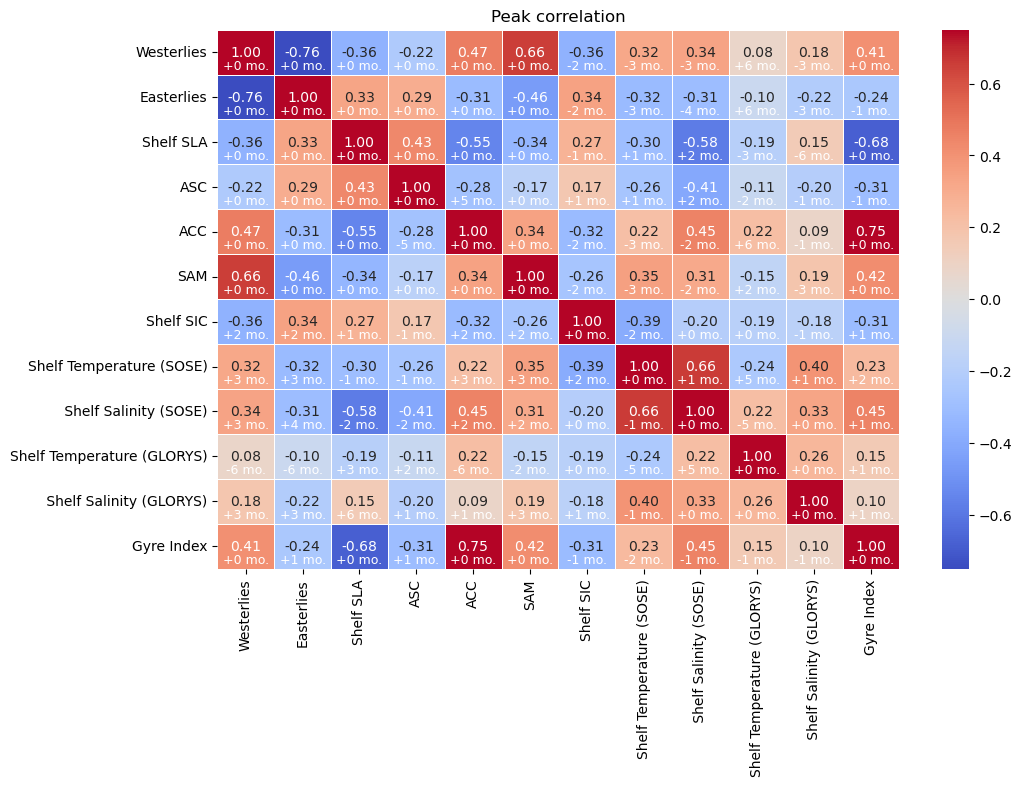

In [76]:
lbls = ['Westerlies','Easterlies','Shelf SLA','ASC','ACC','SAM','Shelf SIC','Shelf Temperature (SOSE)',' Shelf Salinity (SOSE)','Shelf Temperature (GLORYS)',' Shelf Salinity (GLORYS)','Gyre Index']#,'sd2']
matt = pd.DataFrame(cmat,columns=lbls,index=lbls)

fig,ax = plt.subplots(figsize=(11,7))
sns.heatmap(matt, ax=ax, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5,vmin=-0.75,vmax=0.75)
ax.set_title("Peak correlation")

#matl = pd.DataFrame(lmat,columns=lbls,index=lbls)
# plt.figure(figsize=(6,4))
# sns.heatmap(matt, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5,vmin=-12,vmax=23)
# plt.title("Correlation Heatmap")
# plt.show()

#ax=plt.gca()

for i in range (lmat.shape[0]):
  for j in range(lmat.shape[1]):
    lag = lmat[i,j]
    if lag >-1:
      txt = f'+{lag:.0f} mo.'
    else:
      txt = f'{lag:.0f} mo.'
    ax.text(i + 0.5, j + 0.8, txt,
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=9,
            color='w')

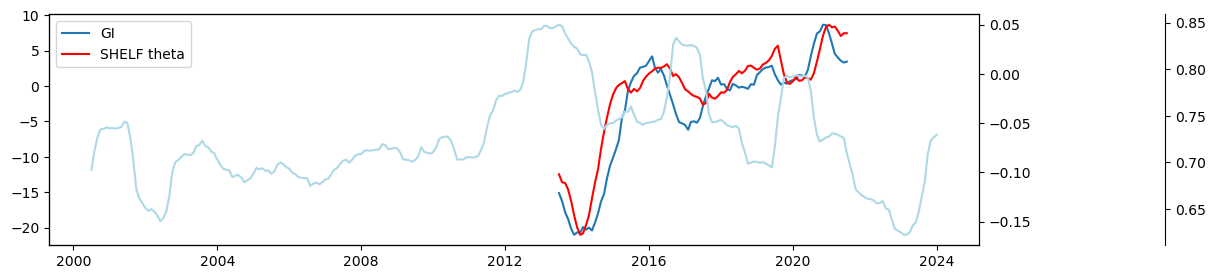

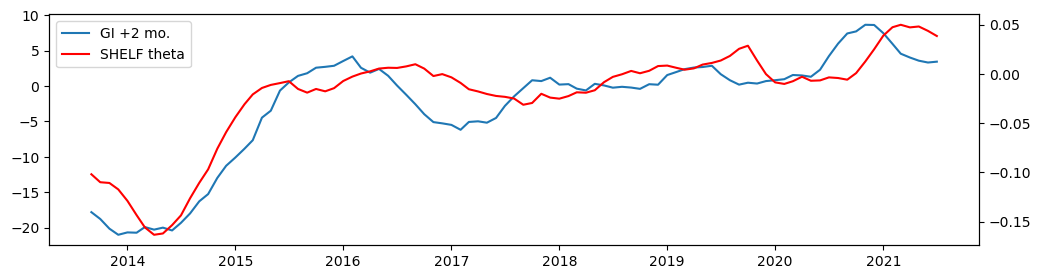

In [ ]:
a = fns.seasonal_anomaly(gyre_index)
alabel='GI'
b = fns.seasonal_anomaly(sthe)
blabel='SHELF theta'
lag=2

a,b = xr.align(a,b)
fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')

twin2=ax.twinx()
twin2.spines.right.set_position(("axes", 1.2))

l3 = twin2.plot(csic.time,csic.rolling({'time':12},center=True).mean(),c='lightblue')
ax.legend(l1+l2,[alabel,blabel])

a,b = xr.align(a,mshift(b,lag))
fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel + ' ' + laglbl(lag),blabel])

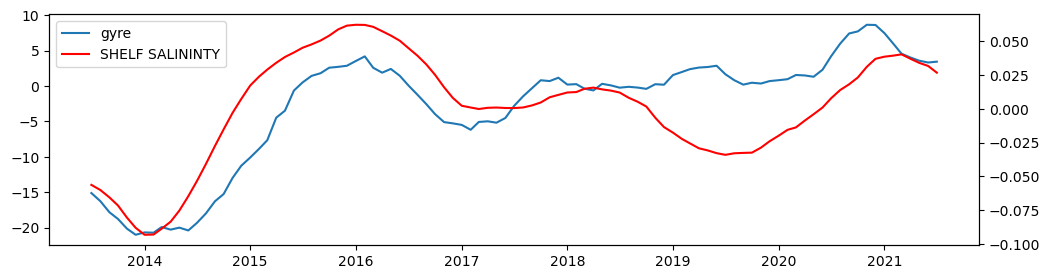

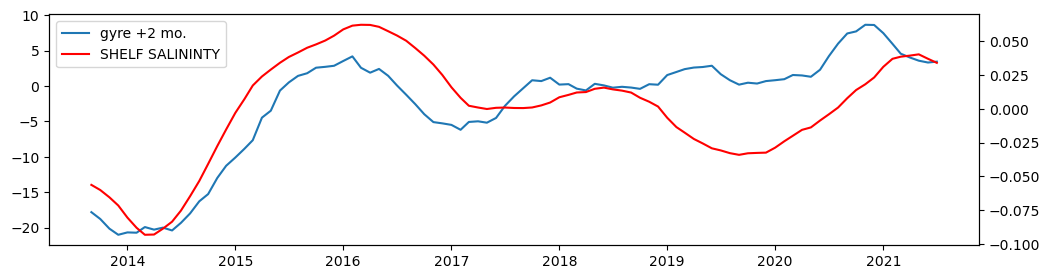

In [ ]:
a = fns.seasonal_anomaly(gyre_index)
alabel='gyre'
b = fns.seasonal_anomaly(ssal)
blabel='SHELF SALININTY'
lag=2

a,b = xr.align(a,b)
fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])

a,b = xr.align(a,mshift(b,lag))
fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel + ' ' + laglbl(lag),blabel])


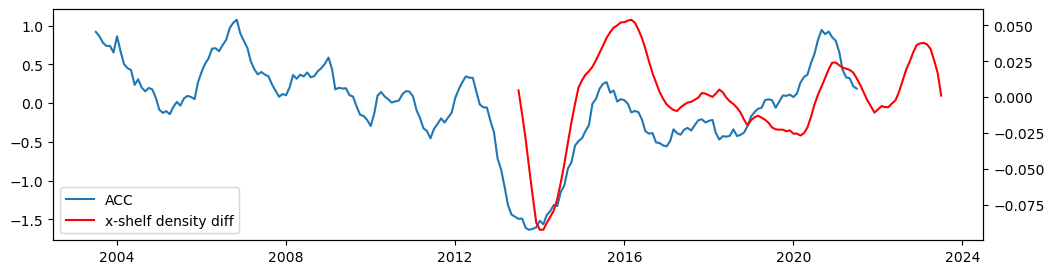

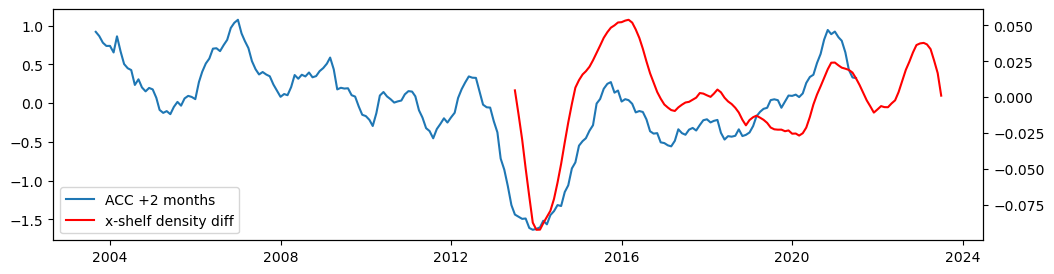

In [46]:
a = fns.seasonal_anomaly(acc)
alabel='ACC'
b = fns.seasonal_anomaly(sigdiff)
blabel='x-shelf density diff'

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.shift({'time':2}).rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel+ ' +2 months',blabel])

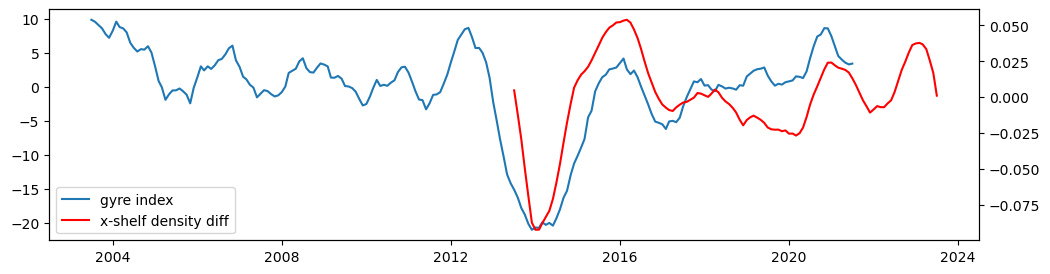

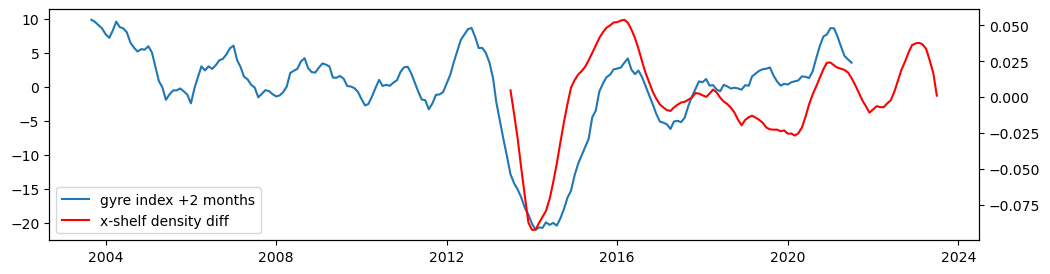

In [47]:
a = fns.seasonal_anomaly(gyre_index)
alabel='gyre index'
b = fns.seasonal_anomaly(sigdiff)
blabel='x-shelf density diff'

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.shift({'time':2}).rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel+ ' +2 months',blabel])

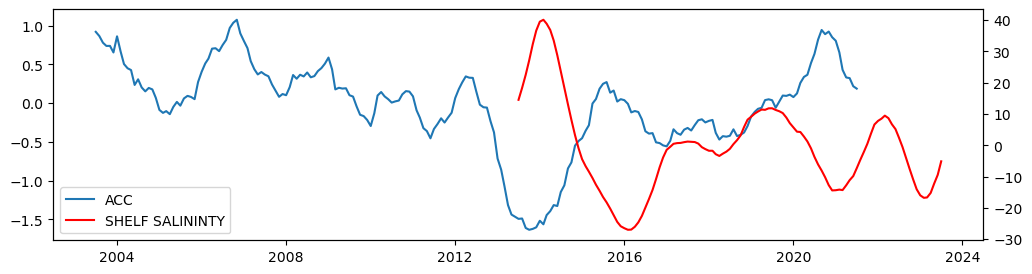

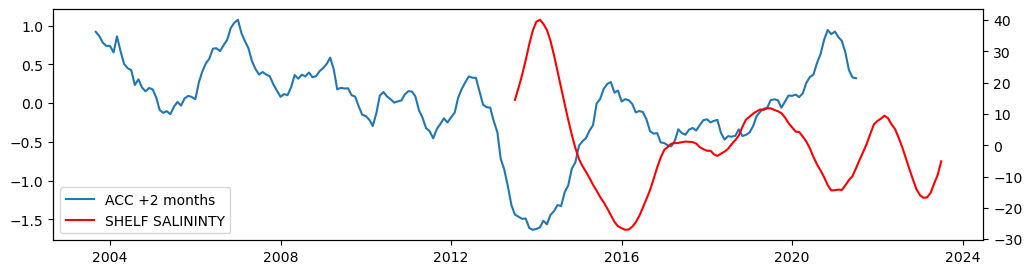

In [48]:
a = fns.seasonal_anomaly(acc)
alabel='ACC'
b = fns.seasonal_anomaly(sose145.SALT.integrate('Z').mean(['YC']))
blabel='SHELF SALININTY'

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.shift({'time':2}).rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel+ ' +2 months',blabel])

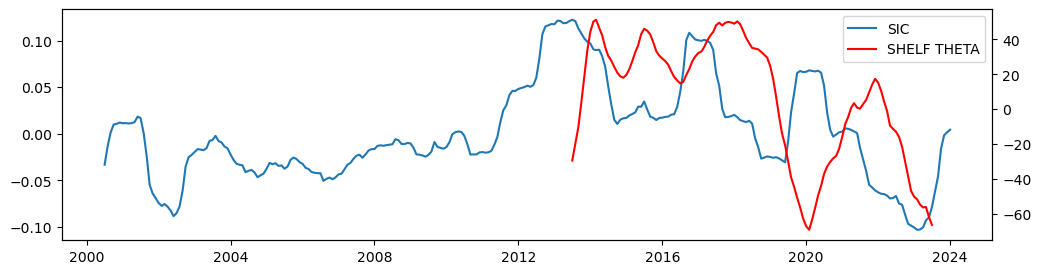

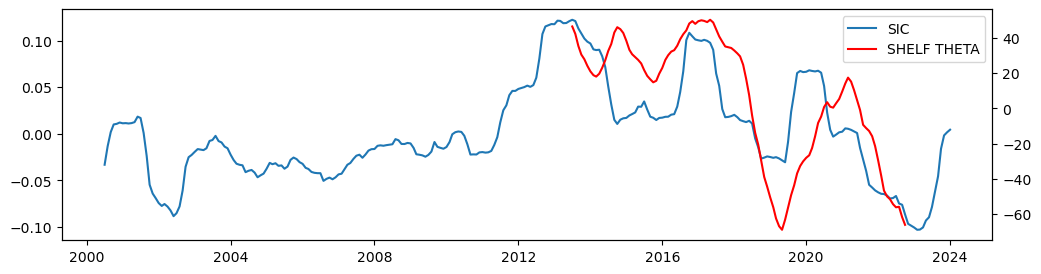

In [49]:
a = fns.seasonal_anomaly(csic)
alabel='SIC'
b = fns.seasonal_anomaly(sose145.THETA.integrate('Z').mean(['YC']))
blabel='SHELF THETA'

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.shift({'time':-9}).rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])


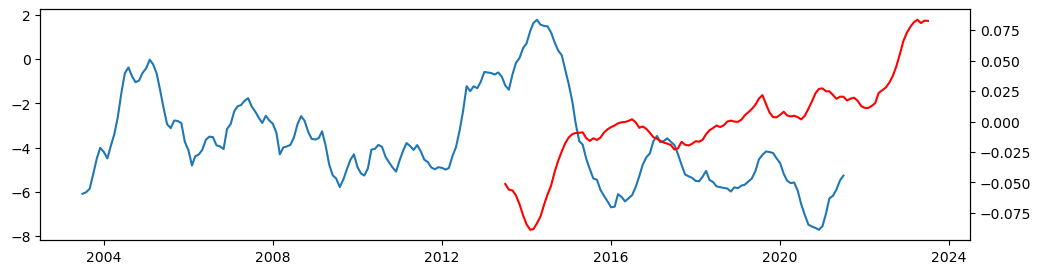

In [50]:
fig, ax = plt.subplots(1,1,figsize=(12,3))
ax.plot(cssh.time,cssh.rolling({'time':12},center=True).mean())
ax.twinx().plot(var1.time,var1.rolling({'time':12},center=True).mean(),c='r')